In [1]:
using Pkg
Pkg.activate(".")
# Pkg.instantiate()
Pkg.status()

  Activating project at `c:\Users\MGAJ\OneDrive - Danmarks Tekniske Universitet\DTU\Kandidat\5_Semester\Speciale\discovering_hidden_physics\scripts`


Status `C:\Users\MGAJ\OneDrive - Danmarks Tekniske Universitet\DTU\Kandidat\5_Semester\Speciale\discovering_hidden_physics\scripts\Project.toml`
⌃ [0f109fa4] BifurcationKit v0.4.16
⌃ [b0b7db55] ComponentArrays v0.15.28
  [a93c6f00] DataFrames v1.7.0
  [0c46a032] DifferentialEquations v7.16.1
  [31c24e10] Distributions v0.25.120
  [f67ccb44] HDF5 v0.17.2
  [0e44f5e4] Hwloc v3.3.0
  [033835bb] JLD2 v0.5.15
  [eec8b66d] KolmogorovArnold v0.0.1
  [a5e1c1ea] LatinHypercubeSampling v1.9.0
⌃ [b2108857] Lux v1.13.5
⌅ [961ee093] ModelingToolkit v9.80.1
  [429524aa] Optim v1.13.2
  [7f7a1694] Optimization v4.5.0
  [36348300] OptimizationOptimJL v0.4.3
  [500b13db] OptimizationPolyalgorithms v0.3.0
  [48d54b35] PEtab v3.8.4 `https://github.com/sebapersson/PEtab.jl.git#PEtabUDEProblem`
⌃ [91a5bcdd] Plots v1.40.14
⌃ [295af30f] Revise v3.8.0
⌃ [1ed8b502] SciMLSensitivity v7.87.0
  [c3572dad] Sundials v4.28.0
⌃ [0c5d862f] Symbolics v6.45.0
  [fe2206b3] TidierData v0.17.0
Info Packages marked with ⌃ a

In [2]:
using Revise, Optimization,Optim, OptimizationOptimJL,OptimizationPolyalgorithms, ModelingToolkit,DifferentialEquations,Plots, Lux, PEtab, Random, Distributions
seed = 0 #set seed for reproducibility
rng = Random.default_rng(seed) #create a random number generator with the seed

┌ Warning: The call to compilecache failed to create a usable precompiled cache file for PEtab [48d54b35-e43e-4a66-a5a1-dde6b987cf69]
│   exception = ErrorException("Required dependency Base.PkgId(Base.UUID(\"b4db0fb7-de2a-5028-82bf-5021f5cfa881\"), \"ReactionNetworkImporters\") failed to load from a cache file.")
└ @ Base loading.jl:2596
┌ Warning: Module PEtab with build ID ffffffff-ffff-ffff-0001-8d5137a2aff1 is missing from the cache.
│ This may mean PEtab [48d54b35-e43e-4a66-a5a1-dde6b987cf69] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2541
┌ Warning: Module PEtab with build ID ffffffff-ffff-ffff-0001-8d5137a2aff1 is missing from the cache.
│ This may mean PEtab [48d54b35-e43e-4a66-a5a1-dde6b987cf69] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2541
┌ Warning: Module PEtab with build ID ffffffff-ffff-ffff-0001-8d5137a2aff1 is missing from the cache.
│ This may mean PEtab [48d54b35-e43e-4a

TaskLocalRNG()

## GENERATE DATA

┌ Warning: To maintain consistency with solution indexing, keyword argument vars will be removed in a future version. Please use keyword argument idxs instead.
│   caller = ip:0x0
└ @ Core :-1


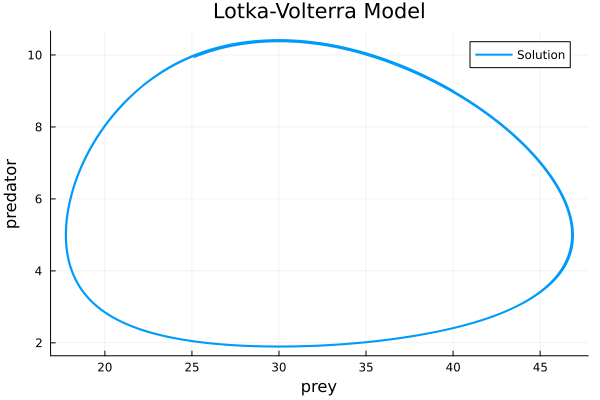

In [3]:
## Lotka-Volterra equations
@parameters α β γ δ
@independent_variables  t
vars = @variables x(t) y(t) z(t)
Dt = Differential(t)
eqs = [
    Dt(x) ~ α * x - β * x * y,
    Dt(y) ~ δ * x * y - γ * y,
]

params =  Dict([α => 0.1, 
                β => 0.02, 
                δ => 0.01,
                γ => 0.3])
measured_quantities = [z ~ x + y]  # Example of a measured quantity
@named sys = ODESystem(eqs, t, [x, y], [α, β, γ, δ]; observed = measured_quantities, defaults = params)
sys = complete(sys)


u0 = Dict([x => 40.0, y => 9.0])
tspan = (0.0, 80.0)
dt = 0.1

sys = complete(sys)
odefun = ODEFunction(sys, unknowns(sys), parameters(sys))
prob = ODEProblem(odefun, [40.0, 9.0], tspan, [0.1, 0.02, 0.01, 0.3])
sol = solve(prob, Tsit5(), saveat=dt)
data = hcat(sol.u...)'
timedata = sol.t
plot(sol, vars=(x, y), xlabel="prey", ylabel="predator",
     title="Lotka-Volterra Model", label="Solution",
     legend=:topright, linewidth=2, markersize=4)


In [4]:
#save model directory
rootdir = dirname(@__DIR__)
model_dir = joinpath(rootdir , "models", "lotka_volterra", "SINDy", "seed_$seed")
#boolean to indicate whether to load models or train models
load_models = true 
model_dir

"c:\\Users\\Marcu\\OneDrive - Danmarks Tekniske Universitet\\DTU\\Kandidat\\5_Semester\\Speciale\\discovering_hidden_physics\\models\\lotka_volterra\\SINDy\\seed_0"

### Known dynamics
These are the dynamics of the species when the other species is not present, i.e. when the other species is in a vacuum.
$$
\begin{align*}
\dot{x} &= \alpha x \\
\dot{y} &= - \gamma y \\
\end{align*}
$$
### Unknown dynamics
The interaction terms between the species, which are not known.
$$
\begin{align*}
\dot{x} &= - \beta xy \\
\dot{y} &= \delta xy
\end{align*}
$$

In [5]:
known_eqs = [
    Dt(x) ~ α * x
    Dt(y) ~ -γ * y
]
unknown_gt_eqs = [
    Dt(x) ~ -β * x * y,
    Dt(y) ~ δ * x * y,
]
deviance = 0.1 # deviance for the unknown_gt equations
params_guess_known = Dict([α => 0.1, # + deviance * randn()
                        γ => 0.3, # + deviance * randn()])
                        ])

params_guess_unknown_gt = Dict([β => 0.02,# + deviance * randn()
                        δ => 0.01 # + deviance * randn()])
                        ])


@named sys_known = ODESystem(known_eqs, t, [x, y], [α, γ], defaults = params_guess_known, observed = measured_quantities)
@named sys_unknown_gt = ODESystem(unknown_gt_eqs, t, [x, y], [β, δ], defaults = params_guess_unknown_gt)
sys_known = complete(sys_known)
sys_unknown_gt = complete(sys_unknown_gt)

Model sys_unknown_gt:
Equations (2):
  2 standard: see equations(sys_unknown_gt)
Unknowns (2): see unknowns(sys_unknown_gt)
  x(t)
  y(t)
Parameters (2): see parameters(sys_unknown_gt)
  β [defaults to 0.02]
  δ [defaults to 0.01]

# Data for fitting


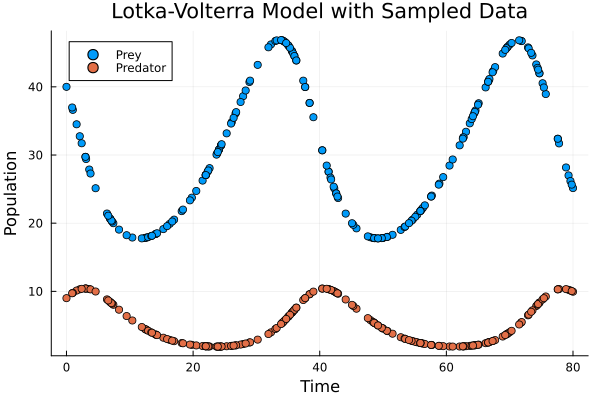

In [6]:
using DataFrames
n_data = size(data, 1)
sample_size = 200

sample_idcs = rand(1:n_data, sample_size)
scatter(timedata[sample_idcs], data[sample_idcs, :], label=["Prey" "Predator"], xlabel="Time", ylabel="Population", title="Lotka-Volterra Model with Sampled Data")

In [7]:
#split train and test data at 80% of the time series
train_fraction = 0.8
test_time = timedata[1:round(Int, n_data * train_fraction)]

prey_df = DataFrame(simulation_id = "cond1", obs_id = "prey_o", time = timedata[sample_idcs], measurement= data[sample_idcs, 1],)
predator_df = DataFrame(simulation_id = "cond1", obs_id = "predator_o", time = timedata[sample_idcs], measurement= data[sample_idcs, 2],)
measurements = vcat(prey_df, predator_df)

#split dataframe into train and test sets
train_idcs = findall(measurements.time .<= test_time[end])
test_idcs = findall(measurements.time .> test_time[end])
#save train and test data½
train_measurements = measurements[train_idcs, :]
test_measurements = measurements[test_idcs, :]

Row,simulation_id,obs_id,time,measurement
,String,String,Float64,Float64
1,cond1,prey_o,75.7,38.9431
2,cond1,prey_o,70.0,46.1909
3,cond1,prey_o,68.9,44.8807
4,cond1,prey_o,66.2,39.9148
5,cond1,prey_o,65.1,37.5907
6,cond1,prey_o,74.7,41.9844
7,cond1,prey_o,64.6,36.5322
8,cond1,prey_o,66.6,40.7419
9,cond1,prey_o,69.6,45.7837


## Regression
Model regression is done by using the ground truth system, which is the Lotka-Volterra system with the interaction terms.


In [3]:
include("../src/hybrid_model.jl")
# hmodel = HybridModel(sys_known, sys_unknown_gt; rng = rng)
hmodel = HybridModel(sys_known, sys_unknown_gt; rng = rng)

initp = init_params(hmodel)
### ENSEMBLE DATA ###

# initial_conditions  = [
#     [40.0, 9.00],
#     [20.0, 8.0],
#     [10, 7.0], 
# ]

# initial_conditions  = [
#     Dict([x => 40.0, y => 9.0]),
#     Dict([x => 20.0, y => 8.0]),
#     Dict([x => 10.0, y => 7.0]),
# ]

initial_conditions = Dict(
    "cond1" => Dict([x => 40.0, y => 9.0]), #remember to define variables before using them
)

ens_prob = EnsembleProblem(hmodel, initial_conditions, tspan, initp)
sol = solve(ens_prob, Rodas5(), EnsembleDistributed(), trajectories = length(initial_conditions), saveat = dt)
scatter(timedata[sample_idcs], data[sample_idcs, :], label=["Prey_data" "Predator_data"], xlabel="Time", ylabel="Population", title="Lotka-Volterra Model with Sampled Data", legend =:topright)
plot!(sol, label = ["Prey_model" "Predator_model"], linewidth=2, markersize=4, legend =:topright)
# savefig(joinpath(plotsdir, "LV_SINDy_sampled_data_gone_wrong.png"))

┌ Warning: Module PEtab with build ID ffffffff-ffff-ffff-0001-8d5137a2aff1 is missing from the cache.
│ This may mean PEtab [48d54b35-e43e-4a66-a5a1-dde6b987cf69] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2541


UndefVarError: UndefVarError: `sys_known` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [4]:
alpha = 0.0 # Lasso penalty
l1_ratio = 0.5 # Lasso/Ridge ratio
obs = Dict("prey_o" => x, "predator_o" => y)
u0map = Dict([x => 40.0, y => 9.0])
peprob = HybridPEProblem(hmodel, obs, train_measurements, u0map; 
                   conditions = initial_conditions)

UndefVarError: UndefVarError: `x` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [88]:
initp_samples = init_params(hmodel; n = 10)

10-element Vector{@NamedTuple{sys::@NamedTuple{α::Float64, γ::Float64}, surrogate::@NamedTuple{δ::Float64, β::Float64}}}:
 (sys = (α = 0.5555555555555556, γ = -0.7777777777777778), surrogate = (δ = 0.11111111111111116, β = -1.0))
 (sys = (α = -0.11111111111111116, γ = -0.33333333333333337), surrogate = (δ = -0.11111111111111116, β = -0.33333333333333337))
 (sys = (α = 0.33333333333333326, γ = 1.0), surrogate = (δ = 1.0, β = 0.5555555555555556))
 (sys = (α = -0.33333333333333337, γ = -1.0), surrogate = (δ = 0.5555555555555556, β = -0.11111111111111116))
 (sys = (α = 0.7777777777777777, γ = -0.11111111111111116), surrogate = (δ = 0.7777777777777777, β = -0.7777777777777778))
 (sys = (α = -0.7777777777777778, γ = 0.11111111111111116), surrogate = (δ = -1.0, β = 0.11111111111111116))
 (sys = (α = -0.5555555555555556, γ = 0.7777777777777777), surrogate = (δ = -0.5555555555555556, β = 1.0))
 (sys = (α = 0.11111111111111116, γ = 0.33333333333333326), surrogate = (δ = 0.33333333333333326, β = 

In [92]:
# opt_func = Optimization.OptimizationProblem(problem, initp_samples[1])
ens_opt_prob_reg = EnsembleProblem(peprob, initp_samples, adalg = Optimization.AutoForwardDiff())

MethodError: MethodError: no method matching (OptimizationProblem{true})(::OptimizationFunction{true, AutoForwardDiff{nothing, Nothing}, var"#1026#1027"{var"#loss_function#1019"{Tuple{Float64, Float64}, Tsit5{typeof(OrdinaryDiffEqCore.trivial_limiter!), typeof(OrdinaryDiffEqCore.trivial_limiter!), Static.False}, EnsembleDistributed, Float64, Float64, Bool, Float64, ForwardDiffSensitivity{0, nothing}, HybridModel, Dict{String, Num}, DataFrame, Float64, Vector{Int64}, Dict{String, Int64}, Dict{SymbolicUtils.BasicSymbolic{Real}, RuntimeGeneratedFunctions.RuntimeGeneratedFunction{(:ˍ₋arg1,), Symbolics.var"#_RGF_ModTag", Symbolics.var"#_RGF_ModTag", (0x14755f58, 0xf0246a09, 0x25d27e53, 0x09c81b19, 0x50f81832), Expr}}, Dict{String, Dict{Num, Float64}}}}, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, typeof(SciMLBase.DEFAULT_OBSERVED_NO_TIME), Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing,

In [62]:
adalg = Optimization.AutoForwardDiff() #Optimization.AutoZygote() # Optimization.AutoReverseDiff(compile=false) # 
optfun = OptimizationFunction((p, p_useless) -> peprob.obj_func(p), adalg)
p_guess = initp .* eps(Float64) # Numerically small initial guess
optprobreg = OptimizationProblem(optfun, p_guess)#, lb = zeros(length(initp)), ub = ones(length(initp)) .* 1e1)


OptimizationProblem. In-place: true
u0: ComponentVector{Float64}(sys = (α = 2.2204460492503132e-17, γ = 6.661338147750939e-17), surrogate = (β = 4.440892098500626e-18, δ = 2.220446049250313e-18))

In [14]:
using JLD2
Reg_dir = joinpath(rootdir , "models", "lotka_volterra", "Reg", "seed_$seed")
if !isdir(Reg_dir)
    mkpath(Reg_dir)
end

In [15]:
#load model
if load_models
    opt_sol_reg_loaded = load(joinpath(Reg_dir, "opt_sol_reg.jld2"), "opt_sol_reg")
    @show opt_sol_reg_loaded
end

┌ Warning: some parameters could not be resolved for type OptimizationBase.var"#grad#16"{SciMLBase.NullParameters,OptimizationFunction{true,AutoForwardDiff{nothing, Nothing},Main.#141#142,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,typeof(SciMLBase.DEFAULT_OBSERVED_NO_TIME),Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing},AutoForwardDiff{nothing, Nothing}}; reconstructing
└ @ JLD2 C:\Users\Marcu\.julia\packages\JLD2\SgtOb\src\data\reconstructing_datatypes.jl:584
┌ Warning: type OptimizationFunction{true,AutoForwardDiff{nothing, Nothing},Main.#141#142,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,typeof(SciMLBase.DEFAULT_OBSERVED_NO_TIME),Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing,Nothing} does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\Marcu\.julia\packages\JLD2\SgtOb\src\data\reconstructing_data

opt_sol_reg_loaded = retcode: Success
u: (sys = (α = 0.0021918193259359954, γ = 1.8281033680494803), surrogate = (β = 0.0064030944747149226, δ = 0.054476749815540335))
Final objective value:     46.441965446209586



retcode: Success
u: ComponentVector{Float64}(sys = (α = 0.0021918193259359954, γ = 1.8281033680494803), surrogate = (β = 0.0064030944747149226, δ = 0.054476749815540335))

In [80]:
opt_sol_reg.original.minimizer

UndefVarError: UndefVarError: `opt_sol_reg` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

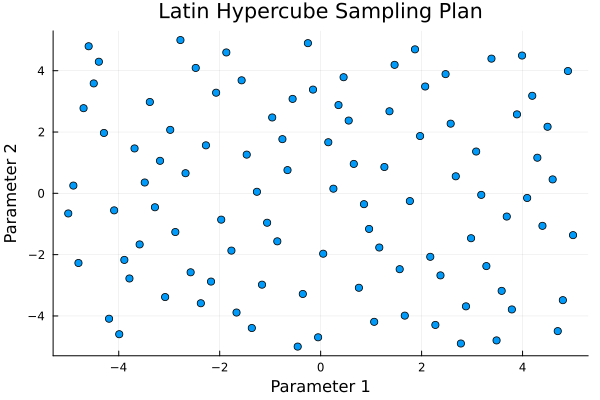

In [17]:
using LatinHypercubeSampling
plan, _ = LHCoptim(100, 2, 1000; rng = rng)

scaled_plan = scaleLHC(plan,[(-5.0,5.0),(-5.0,5.0)])
scatter(scaled_plan[:, 1], scaled_plan[:, 2], xlabel="Parameter 1", ylabel="Parameter 2", title="Latin Hypercube Sampling Plan", legend=false)

### Ensemble Optimization

In [18]:
initp_samples = init_params(hmodel; n = 10)
function prob_func(prob, i, repeat)
    
    remake(prob, u0 = 1e-0* randn(length(initp)).+p_guess) 
end

prob_func (generic function with 1 method)

In [ ]:
opt_n = 3 #number of optimization runs
ensembleoptprob = Optimization.EnsembleProblem(optprobreg; prob_func)
ensembleoptsol = Optimization.solve(ensembleoptprob, PolyOpt(),
    EnsembleThreads(), trajectories = opt_n, maxiters = 100)

┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase C:\Users\Marcu\.julia\packages\SciMLBase\sN1tQ\src\integrator_interface.jl:589
┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase C:\Users\Marcu\.julia\packages\SciMLBase\sN1tQ\src\integrator_interface.jl:589
┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the defaul

In [20]:

ensembleoptsol 
save(joinpath(Reg_dir, "opt_sol_reg_ensemble.jld2"), "ensembleoptsol", ensembleoptsol)

UndefVarError: UndefVarError: `ensembleoptsol` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [21]:
#load model
ensembleoptsol_loaded = load(joinpath(Reg_dir, "opt_sol_reg_ensemble.jld2"), "ensembleoptsol")
ensembleoptsol_loaded[1].original.initial_x

UndefVarError: UndefVarError: `load` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [22]:
sol_idx = idx_sim
ens_prob = EnsembleProblem(hmodel, initial_conditions, tspan, optsol[sol_idx].u)
sol = solve(ens_prob, Rodas5(), EnsembleDistributed(), trajectories = length(initial_conditions), saveat = dt)
scatter(timedata[sample_idcs], data[sample_idcs, :], label=["Prey_data" "Predator_data"], xlabel="Time", ylabel="Population", title="Lotka-Volterra Model: Loss $(round(optsol[sol_idx].objective,sigdigits = 3))", legend =:topright)
plot!(sol, label = ["Prey_model" "Predator_model"], linewidth=2, markersize=4, legend =:topright)
# savefig(joinpath(plotsdir, "LV_SINDy_res_1.png"))

UndefVarError: UndefVarError: `idx_sim` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## SINDy




Assuming only partial knowledge of the Lotka-Volterra equations, we can use SINDy to discover the hidden dynamics.
It's assumed the known dynamics are the ones known whenever a species is present in a vacuum, i.e. when the other species is not present. It's desired to discover the interaction terms between the species, which are not known.



### Proposed basis for SINDy library

In [23]:
function polynomial_basis(x::Array, degree::Int = 1)
    @assert degree > 0
    n_x = length(x)
    n_c = binomial(n_x + degree, degree)
    eqs = Array{Num}(undef, n_c)
    _check_degree(x) = sum(x) <= degree ? true : false
    itr = Base.Iterators.product([0:degree for i in 1:n_x]...)
    itr_ = Base.Iterators.Stateful(Base.Iterators.filter(_check_degree, itr))
    filled = false
    @inbounds for i in 1:n_c
        eqs[i] = 1
        filled = true
        for (xi, ci) in zip(x, popfirst!(itr_))
            if !iszero(ci)
                filled ? eqs[i] = xi^ci : eqs[i] *= xi^ci
                filled = false
            end
        end
    end
    eqs
end

species = unknowns(sys_known)
unknown_basis = polynomial_basis(species, 2) 

6-element Vector{Num}:
         1
      x(t)
    x(t)^2
      y(t)
 x(t)*y(t)
    y(t)^2

In [24]:
using Symbolics, Base

In [25]:
Base.occursin(needle::Num, haystack::Int64) = false # Override occursin for Num types to always return false whenever haystack is an Int64
function create_unknown_eqs(sys_known::AbstractTimeDependentSystem, unknown_basis::Vector{T}; Ξ = nothing) where T <: Union{Num}
    #remove basis functions that are already in the known system
    if isnothing(Ξ)
        @parameters Ξ[1:length(unknown_basis), 1:length(unknowns(sys_known))]
    end 
    known_species = unknowns(sys_known)
    known_eqs = equations(sys_known)
    Ξ = hcat(Ξ)
    #create empty vector to hold the unknown equations
    unknown_eqs = Vector{Any}(undef, length(known_eqs))
    #if equation is already in the known system, remove it from the unknown basis
    for (i,k_eq) in enumerate(known_eqs)
        eq_basis_funs = copy(unknown_basis)
        for (j, basis_fun) in enumerate(unknown_basis)
            if occursin(basis_fun, k_eq.rhs)
                eq_basis_funs[j] = 0
            end
        end
        unknown_eqs[i] = Equation(k_eq.lhs, sum(eq_basis_funs .* Ξ[i, :]))
    end 
    return unknown_eqs
end

create_unknown_eqs (generic function with 1 method)

In [26]:
plotsdir = joinpath(rootdir, "plots", "lotka_volterra", "SINDy", "seed_$seed")

"c:\\Users\\Marcu\\OneDrive - Danmarks Tekniske Universitet\\DTU\\Kandidat\\5_Semester\\Speciale\\discovering_hidden_physics\\plots\\lotka_volterra\\SINDy\\seed_0"

In [27]:
#makedir if it does not exist
using FileIO
if !isdir(plotsdir)
    mkpath(plotsdir)
end

ArgumentError: ArgumentError: Package FileIO not found in current path.
- Run `import Pkg; Pkg.add("FileIO")` to install the FileIO package.

In [28]:
@parameters Ξ[1:length(known_eqs), 1:length(unknown_basis)]
default_params = Dict([Ξ[i, j] => eps(Float64) for i in 1:length(known_eqs), j in 1:length(unknown_basis)])
# default_params[Ξ[1,5]] = - params[β]
# default_params[Ξ[2,5]] = params[δ] # Set the default parameters for the unknown equations

uk_eqs = create_unknown_eqs(sys_known, unknown_basis; Ξ = Ξ)
@named sys_SINDy = ODESystem(uk_eqs, t, defaults = default_params)
sys_SINDy = complete(sys_SINDy)

Model sys_SINDy:
Equations (2):
  2 standard: see equations(sys_SINDy)
Unknowns (2): see unknowns(sys_SINDy)
  x(t)
  y(t)
Parameters (10): see parameters(sys_SINDy)
  Ξ[1, 3] [defaults to 2.22045e-16]
  Ξ[2, 5] [defaults to 2.22045e-16]
  Ξ[1, 5] [defaults to 2.22045e-16]
  Ξ[1, 6] [defaults to 2.22045e-16]
  ⋮

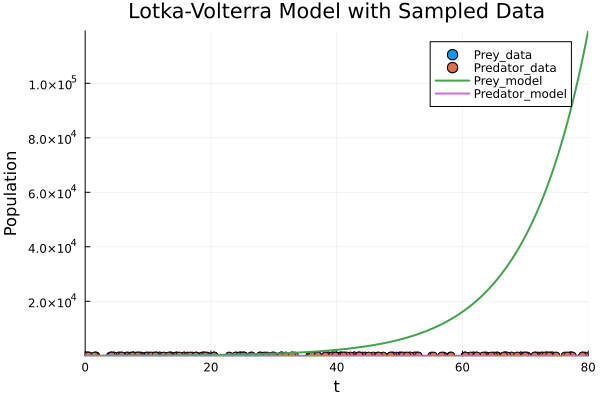

In [29]:
include("../src/hybrid_model.jl")
# hmodel = HybridModel(sys_known, sys_unknown_gt; rng = rng)
hmodel = HybridModel(sys_known, sys_SINDy; rng = rng)

initp = init_params(hmodel)
### ENSEMBLE DATA ###

# initial_conditions  = [
#     [40.0, 9.00],
#     [20.0, 8.0],
#     [10, 7.0], 
# ]

# initial_conditions  = [
#     Dict([x => 40.0, y => 9.0]),
#     Dict([x => 20.0, y => 8.0]),
#     Dict([x => 10.0, y => 7.0]),
# ]

initial_conditions = Dict(
    "cond1" => Dict([x => 40.0, y => 9.0]), #remember to define variables before using them
)

ens_prob = EnsembleProblem(hmodel, initial_conditions, tspan, initp)
sol = solve(ens_prob, Rodas5(), EnsembleDistributed(), trajectories = length(initial_conditions), saveat = dt)
scatter(timedata[sample_idcs], data[sample_idcs, :], label=["Prey_data" "Predator_data"], xlabel="Time", ylabel="Population", title="Lotka-Volterra Model with Sampled Data", legend =:topright)
plot!(sol, label = ["Prey_model" "Predator_model"], linewidth=2, markersize=4, legend =:topright)
# savefig(joinpath(plotsdir, "LV_SINDy_sampled_data_gone_wrong.png"))

## Model Fitting


In [30]:
alpha = 1e-3 # Lasso penalty
l1_ratio = 0.5 # Lasso/Ridge ratio

obs = Dict("prey_o" => x, "predator_o" => y)
u0map = Dict([x => 40.0, y => 9.0])
peprob = HybridPEProblem(hmodel, obs, train_measurements, u0map; 
                   conditions = initial_conditions, include_plot = false,
                   ens_alg = EnsembleDistributed(),
                   alg = Rosenbrock23(),
                      alpha = alpha,
                      l1_ratio = l1_ratio
                   );

In [31]:
adalg = Optimization.AutoForwardDiff() #Optimization.AutoZygote() # Optimization.AutoReverseDiff(compile=false) # 
optfun = OptimizationFunction((p, p_useless) -> peprob.obj_func(p), adalg)
p_guess = initp .* eps(Float64)
optprob = OptimizationProblem(optfun, p_guess)#, lb = zeros(length(initp)), ub = ones(length(initp)) .* 1e1)


OptimizationProblem. In-place: true
u0: ComponentVector{Float64}(sys = (α = 2.2204460492503132e-17, γ = 6.661338147750939e-17), surrogate = (Ξ[1, 3] = 4.930380657631324e-32, Ξ[2, 5] = 4.930380657631324e-32, Ξ[1, 5] = 4.930380657631324e-32, Ξ[1, 6] = 4.930380657631324e-32, Ξ[2, 3] = 4.930380657631324e-32, Ξ[1, 1] = 4.930380657631324e-32, Ξ[2, 1] = 4.930380657631324e-32, Ξ[2, 6] = 4.930380657631324e-32, Ξ[1, 4] = 4.930380657631324e-32, Ξ[2, 2] = 4.930380657631324e-32))

In [32]:
sol = solve(optprob, Optim.BFGS(); maxiters = 100,
            show_trace = true, show_every = 5)

Iter     Function value   Gradient norm 
     0     1.359835e+02     6.056399e+05
 * Current step size: 1.0
 * time: 0.006999969482421875
 * g(x): (sys = (α = 15140.997867860442, γ = -1047.354137546878), surrogate = (Ξ[1, 3] = 605639.9147159801, Ξ[2, 5] = 41894.16550343769, Ξ[1, 5] = 136268.98081230622, Ξ[1, 6] = 30660.52068397977, Ξ[2, 3] = 186196.291121008, Ξ[1, 1] = 378.52494825901044, Ξ[2, 1] = 116.37268351215334, Ξ[2, 6] = 9426.187239484392, Ξ[1, 4] = 3406.7245218310914, Ξ[2, 2] = 4654.907279548631))
 * ~inv(H): [1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0; 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0

┌ Warning: At t=8.128784688675727e-6, dt was forced below floating point epsilon 1.6940658945086007e-21, and step error estimate = 12.670751438970349. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of ForwardDiff.Dual{ForwardDiff.Tag{var"#189#190", Float64}, Float64, 12}).
└ @ SciMLBase C:\Users\Marcu\.julia\packages\SciMLBase\sN1tQ\src\integrator_interface.jl:623
┌ Warning: At t=8.117100939796313e-6, dt was forced below floating point epsilon 1.6940658945086007e-21, and step error estimate = 1.5607609513297485. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase C:\Users\Marcu\.julia\packages\SciMLBase\sN1tQ\src\integrator_interface.jl:623
┌ Warning: At t=8.128778625161892e-5, dt was forced below floating point epsilon 1.3552527156068805e-20, an

     5     6.199612e+01     4.046451e+04
 * Current step size: 3.4166743610627337e-6
 * time: 1.8600001335144043
 * g(x): (sys = (α = 1186.4827919949917, γ = 87.55100363950946), surrogate = (Ξ[1, 3] = 40464.50874452222, Ξ[2, 5] = -2998.5308090483363, Ξ[1, 5] = 4703.849254822691, Ξ[1, 6] = 626.9053710853511, Ξ[2, 3] = -29146.10603213581, Ξ[1, 1] = 35.22454716607563, Ξ[2, 1] = -27.937342682678207, Ξ[2, 6] = -374.8408970206261, Ξ[1, 4] = 132.9669654286297, Ξ[2, 2] = -896.1761279672415))
 * ~inv(H): [0.40058526720389676 0.039521428651397766 -0.011178342506254373 0.01021713223346743 -0.12344495559627534 0.48879950974689007 0.01045750496370064 -0.0524265694148599 -0.016194887559275103 0.10261846510596684 -0.10336439222758564 -0.1845572906009435; 0.039521428651397794 0.9964594606064107 -0.001493235420195679 0.03437556592488847 0.0054218795884537485 -0.0236932463304948 -0.0007929903638537574 0.003459718927447125 0.000985685797352974 -0.0036373545610928065 0.0067993838000002665 0.01102571579612

┌ Warning: At t=0.0008275847270138903, dt was forced below floating point epsilon 1.0842021724855044e-19, and step error estimate = 213.39547113461032. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of ForwardDiff.Dual{ForwardDiff.Tag{var"#189#190", Float64}, Float64, 12}).
└ @ SciMLBase C:\Users\Marcu\.julia\packages\SciMLBase\sN1tQ\src\integrator_interface.jl:623
┌ Warning: At t=0.0008281358284810287, dt was forced below floating point epsilon 1.0842021724855044e-19, and step error estimate = 1.5607613331560497. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase C:\Users\Marcu\.julia\packages\SciMLBase\sN1tQ\src\integrator_interface.jl:623
┌ Warning: At t=0.008288078140913587, dt was forced below floating point epsilon 1.734723475976807e-18, a

    10     4.455375e+01     1.073533e+02
 * Current step size: 2.4533582258779925
 * time: 2.1600000858306885
 * g(x): (sys = (α = 1.325228941967676, γ = -1.0919534787810572), surrogate = (Ξ[1, 3] = 32.22178101198908, Ξ[2, 5] = 29.08754434942704, Ξ[1, 5] = 12.607520852333709, Ξ[1, 6] = 2.9155302318452394, Ξ[2, 3] = 107.35332439015947, Ξ[1, 1] = 0.052963518862037796, Ξ[2, 1] = 0.16495868786561899, Ξ[2, 6] = 6.478386229045316, Ξ[1, 4] = 0.46567938644014095, Ξ[2, 2] = 4.257752486787468))


┌ Warning: At t=0.43332274106468466, dt was forced below floating point epsilon 5.551115123125783e-17, and step error estimate = 1.0098139886508513. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of ForwardDiff.Dual{ForwardDiff.Tag{var"#189#190", Float64}, Float64, 12}).
└ @ SciMLBase C:\Users\Marcu\.julia\packages\SciMLBase\sN1tQ\src\integrator_interface.jl:623
┌ Warning: At t=0.43548433148025895, dt was forced below floating point epsilon 5.551115123125783e-17, and step error estimate = 1.5607612690942116. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase C:\Users\Marcu\.julia\packages\SciMLBase\sN1tQ\src\integrator_interface.jl:623
┌ Warning: At t=0.49726736604417826, dt was forced below floating point epsilon 5.551115123125783e-17, and step

 * ~inv(H): [0.8481141509973404 0.7118015505707732 -0.03732357354230502 -0.05530243909096681 0.13172401983069232 0.19951822626741317 -0.011464300995071057 0.7510502797441969 0.4457178711158444 0.4255946199218057 -4.123564289200661 0.12602490423046564; 0.7118015505707732 1.7419318055433632 -0.033558211183454374 -0.00916843966436065 0.12148055360980609 0.18113657649476905 -0.021317668590278466 0.7632819129823192 0.42269200478666014 0.3761740233298974 -3.5886332538159493 0.41901600131961125; -0.03732357354230504 -0.033558211183454374 0.0016522694629614544 0.0023780311145847714 -0.005842925488402619 -0.008914050566028951 0.0005359584393438727 -0.03561219672236285 -0.02002535569381902 -0.018841205518979345 0.18280170238651117 -0.00636904047410917; -0.05530243909096681 -0.009168439664360649 0.0023780311145847714 0.004913983614834545 -0.008350691600498606 -0.012609470142118596 0.0003554477806659443 -0.05464984422314459 -0.029367072947110124 -0.027734965590962404 0.2681538417052783 0.002642386

┌ Warning: At t=0.11865042779473088, dt was forced below floating point epsilon 1.3877787807814457e-17, and step error estimate = 15.82405960106384. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of ForwardDiff.Dual{ForwardDiff.Tag{var"#189#190", Float64}, Float64, 12}).
└ @ SciMLBase C:\Users\Marcu\.julia\packages\SciMLBase\sN1tQ\src\integrator_interface.jl:623
┌ Warning: At t=0.11870405620451466, dt was forced below floating point epsilon 1.3877787807814457e-17, and step error estimate = 1.5607611344521426. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase C:\Users\Marcu\.julia\packages\SciMLBase\sN1tQ\src\integrator_interface.jl:623


    15     4.213370e+01     3.495789e+01
 * Current step size: 0.04516323237370275
 * time: 2.513000011444092
 * g(x): (sys = (α = 1.3671060440790466, γ = 0.07589831186625769), surrogate = (Ξ[1, 3] = 34.957891470644974, Ξ[2, 5] = -4.750255836342301, Ξ[1, 5] = 3.2045862270195813, Ξ[1, 6] = -0.025087287346349695, Ξ[2, 3] = -15.508135092650416, Ξ[1, 1] = 0.050906624591848804, Ξ[2, 1] = 0.01714392485084637, Ξ[2, 6] = -1.220254409085227, Ξ[1, 4] = 0.13215292277586366, Ξ[2, 2] = -0.005979122304398378))
 * ~inv(H): [0.021470121057646285 -0.020177133046179963 -0.0007390758075538212 -0.0016320962013706575 0.0018050922177574868 0.006169177249561966 -0.00024152479118891464 -0.0806270735663367 -0.009765002650108698 0.00312261445921537 -0.07344634866903166 0.006594062373983717; -0.020177133046172857 1.1156866600130382 -0.0004539634270025253 0.03970265025276487 0.004971345879292335 -0.017651625954890726 -0.008842503026748383 -0.1709760610777743 -0.06904512971865673 0.007430617296807995 0.14516984845

retcode: Success
u: ComponentVector{Float64}(sys = (α = 0.8728104274774143, γ = -14.437641243479764), surrogate = (Ξ[1, 3] = -0.021959150104680147, Ξ[2, 5] = -0.5604729184941762, Ξ[1, 5] = -0.009221309850036356, Ξ[1, 6] = 0.5981451912697757, Ξ[2, 3] = 0.09303477936833959, Ξ[1, 1] = 2.7783475870063272, Ξ[2, 1] = 1.6099378410114038, Ξ[2, 6] = 0.05747841956850825, Ξ[1, 4] = -5.029633278872187, Ξ[2, 2] = -2.506767143659854))

In [5]:
ens_prob = EnsembleProblem(hmodel, initial_conditions, tspan, sol.u)
ens_sol = solve(ens_prob, Rodas5(), EnsembleDistributed(), trajectories = length(initial_conditions), saveat = dt)
scatter(timedata[sample_idcs], data[sample_idcs, :], label=["Prey_data" "Predator_data"], xlabel="Time", ylabel="Population", title="Lotka-Volterra Model with Sampled Data", legend =:topright)
plot!(ens_sol, label = ["Prey_model" "Predator_model"], linewidth=2, markersize=4, legend =:topright)
# savefig(joinpath(plotsdir, "LV_SINDy_res_2.png"))

UndefVarError: UndefVarError: `hmodel` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [34]:
sol.objective

41.84266653744383

In [35]:
opt_n = 30 #number of optimization runs
ensembleprob = Optimization.EnsembleProblem(optprob; prob_func)
optsol = Optimization.solve(ensembleprob, Optim.LBFGS(),
    EnsembleThreads(), trajectories = opt_n, maxiters = 100)

┌ Warning: At t=5.906977698119187e-5, dt was forced below floating point epsilon 6.776263578034403e-21, and step error estimate = 52.43204670804573. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of ForwardDiff.Dual{ForwardDiff.Tag{var"#189#190", Float64}, Float64, 12}).
└ @ SciMLBase C:\Users\Marcu\.julia\packages\SciMLBase\sN1tQ\src\integrator_interface.jl:623
┌ Warning: At t=5.896958172031569e-5, dt was forced below floating point epsilon 6.776263578034403e-21, and step error estimate = 1.5607610605011748. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase C:\Users\Marcu\.julia\packages\SciMLBase\sN1tQ\src\integrator_interface.jl:623
┌ Warning: At t=0.0005929474348558083, dt was forced below floating point epsilon 1.0842021724855044e-19, and 

AssertionError: AssertionError: isfinite(phi_d) && isfinite(gphi)

In [36]:

#find index of minimum
min_idx = argmin([opt.objective for opt in optsol])
[opt.objective for opt in optsol]

UndefVarError: UndefVarError: `optsol` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [37]:
sol_idx = 7
ens_prob = EnsembleProblem(hmodel, initial_conditions, tspan, optsol[sol_idx].u)
sol = solve(ens_prob, Rodas5(), EnsembleDistributed(), trajectories = length(initial_conditions), saveat = dt)
scatter(timedata[sample_idcs], data[sample_idcs, :], label=["Prey_data" "Predator_data"], xlabel="Time", ylabel="Population", title="Lotka-Volterra Model: Loss $(round(optsol[sol_idx].objective,sigdigits = 3))", legend =:topright)
plot!(sol, label = ["Prey_model" "Predator_model"], linewidth=2, markersize=4, legend =:topright)
# savefig(joinpath(plotsdir, "LV_SINDy_res_1.png"))

UndefVarError: UndefVarError: `optsol` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

## UDEs

In [38]:
# using KolmogorovArnold
# basis_func = KolmogorovArnold.rbf # rbf, rswaf, iqf (radial basis funcs, reflection switch activation funcs, inverse quadratic funcs)
# normalizer = softsign # sigmoid(_fast), tanh(_fast), softsign
# kan1 = Chain(
#     KDense( 2, 40, 10; use_base_act = true, basis_func, normalizer),
#     KDense(40, 40, 10; use_base_act = true, basis_func, normalizer),
#     KDense(40,  2, 10; use_base_act = true, basis_func, normalizer),
# ) # 18_490 parameters plus 30 states.

In [39]:
rbf(x) = exp.(-(x.^2))

nn1 = Lux.Chain(
    Lux.Dense(2,5,rbf; init_weight =  kaiming_normal),
    Lux.Dense(5,5, rbf, init_weight = kaiming_normal),
    Lux.Dense(5,5, rbf, init_weight = kaiming_normal),
    Lux.Dense(5,2, rbf, init_weight = kaiming_normal),
)
p_nn, st_nn = Lux.setup(rng, nn1)

((layer_1 = (weight = Float32[-0.19809864 0.58588284; 0.29630688 1.3444365; … ; -1.2047306 -0.032572605; 1.3373519 -1.0563389], bias = Float32[0.57272375, -0.6701181, 0.04524523, 0.46807632, -0.4881507]), layer_2 = (weight = Float32[-0.003683901 0.6203199 … 1.0269581 1.0949383; -0.7950159 -1.0705047 … 0.5589426 -0.75124717; … ; -0.13387954 0.47839478 … -0.7135911 0.20307943; 0.2045645 -0.46609282 … -0.8039224 -0.6572451], bias = Float32[-0.04172262, -0.031750396, 0.33278155, -0.34465456, -0.19273333]), layer_3 = (weight = Float32[-0.37912074 -0.37494954 … -0.39241043 0.24313459; -0.99516964 0.2180537 … -0.1972487 -0.06506955; … ; 1.0068613 0.45523226 … 0.91912377 -0.34323543; -0.8660381 -0.42531535 … 0.47173464 0.16840021], bias = Float32[-0.4235815, 0.12729587, -0.25820935, -0.19500192, -0.27028573]), layer_4 = (weight = Float32[0.28917342 0.1750916 … -0.60820794 1.075867; -0.9157013 -0.0016635956 … -1.1593579 -0.28984025], bias = Float32[0.2500388, 0.11627057])), (layer_1 = NamedTupl

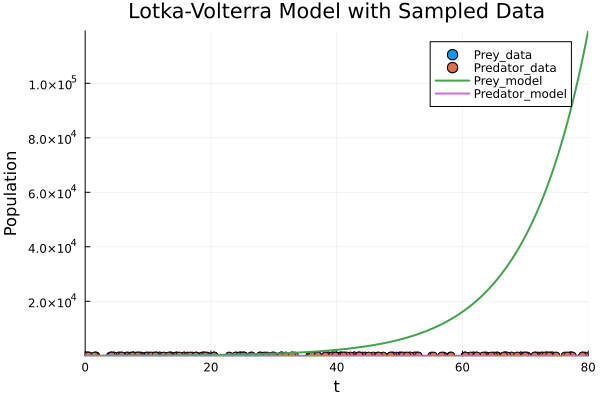

In [48]:
include("../src/hybrid_model.jl")
# hmodel = HybridModel(sys_known, sys_unknown_gt; rng = rng)
hmodel = HybridModel(sys_known, nn1; rng = rng)

initp = init_params(hmodel)
### ENSEMBLE DATA ###

# initial_conditions  = [
#     [40.0, 9.00],
#     [20.0, 8.0],
#     [10, 7.0], 
# ]

# initial_conditions  = [
#     Dict([x => 40.0, y => 9.0]),
#     Dict([x => 20.0, y => 8.0]),
#     Dict([x => 10.0, y => 7.0]),
# ]

initial_conditions = Dict(
    "cond1" => Dict([x => 40.0, y => 9.0]), #remember to define variables before using them
)

ens_prob = EnsembleProblem(hmodel, initial_conditions, tspan, initp)
sol = solve(ens_prob, Rodas5(), EnsembleDistributed(), trajectories = length(initial_conditions), saveat = dt)
scatter(timedata[sample_idcs], data[sample_idcs, :], label=["Prey_data" "Predator_data"], xlabel="Time", ylabel="Population", title="Lotka-Volterra Model with Sampled Data", legend =:topright)
plot!(sol, label = ["Prey_model" "Predator_model"], linewidth=2, markersize=4, legend =:topright)
# savefig(joinpath(plotsdir, "LV_SINDy_sampled_data_gone_wrong.png"))

In [47]:
initp_samples = init_params(hmodel; n = 10)

10-element Vector{@NamedTuple{sys::@NamedTuple{α::Float64, γ::Float64}, surrogate::@NamedTuple{layer_1::@NamedTuple{weight::Matrix{Float32}, bias::Vector{Float32}}, layer_2::@NamedTuple{weight::Matrix{Float32}, bias::Vector{Float32}}, layer_3::@NamedTuple{weight::Matrix{Float32}, bias::Vector{Float32}}, layer_4::@NamedTuple{weight::Matrix{Float32}, bias::Vector{Float32}}}}}:
 (sys = (α = 0.11111111111111116, γ = -0.5555555555555556), surrogate = (layer_1 = (weight = [-0.054622177 -1.2313768; -1.433529 0.32919112; … ; 0.71007085 -1.6446924; -0.8274169 -0.25865692], bias = [-0.4332095, 0.24534634, -0.64800847, 0.5408781, 0.4066809]), layer_2 = (weight = [0.15486626 -0.87181926 … 0.02905728 -0.02459543; 1.0026109 0.2763161 … -0.70397407 1.1992879; … ; -0.07079068 0.38884377 … -0.26358315 0.8351695; -0.9019701 -0.21590741 … 0.030095916 0.036620628], bias = [-0.39972106, 0.004158284, 0.2795915, 0.40788448, 0.3737837]), layer_3 = (weight = [0.5910305 -0.42744747 … -0.63870305 0.47134784; -0.

In [41]:
alpha = 1e-3 # Lasso penalty
l1_ratio = 0.5 # Lasso/Ridge ratio
obs = Dict("prey_o" => x, "predator_o" => y)
u0map = Dict([x => 40.0, y => 9.0])
peprob = HybridPEProblem(hmodel, obs, train_measurements, u0map; 
                   conditions = initial_conditions, include_plot = false,
                   ens_alg = EnsembleSerial(),
                   alg = Rosenbrock23(),
                      alpha = alpha,
                      l1_ratio = l1_ratio
                   );

In [266]:
adalg = Optimization.AutoForwardDiff() #Optimization.AutoZygote() # Optimization.AutoReverseDiff(compile=false) # 
optfun = OptimizationFunction((p, p_useless) -> peprob.obj_func(p), adalg)
p_guess = initp #.* eps(Float64) # Numerically small initial guess
optprobude = OptimizationProblem(optfun, p_guess)#, lb = zeros(length(initp)), ub = ones(length(initp)) .* 1e1)


OptimizationProblem. In-place: true
u0: ComponentVector{Float64}(sys = (α = 0.1, γ = 0.3), surrogate = (layer_1 = (C = [0.027248013764619827 0.06367415189743042 … 0.18133175373077393 -0.31226328015327454; -0.12859034538269043 -0.055464811623096466 … -0.011946835555136204 -0.023036586120724678; … ; 0.06117994338274002 0.18246369063854218 … 0.02133296988904476 0.1537523865699768; 0.04333868622779846 0.11126791685819626 … 0.2946283519268036 0.0046269651502370834], W = [-0.3131815195083618 -0.3172733187675476; 0.010425034910440445 0.3561668395996094; … ; -0.34665733575820923 -0.07513315230607986; 0.36450737714767456 0.3245965838432312]), layer_2 = (C = [0.047993265092372894 -0.1102641150355339 … -0.10455510765314102 0.012062587775290012; 0.031383972615003586 0.0972566083073616 … -0.0460616759955883 0.08438930660486221; … ; -0.028984900563955307 -0.019163411110639572 … -0.0918583869934082 -0.047693051397800446; -0.010761216282844543 0.023074667900800705 … -0.04025590419769287 -0.04882958903

In [ ]:
#solve optimiation problem
opt_sol_ude = solve(optprobude, PolyOpt(), 
            maxiters = 300, 
            show_trace = true, 
            show_every = 10,)

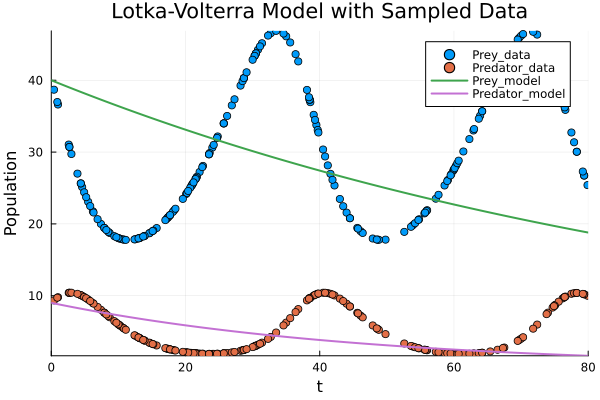

In [261]:
ude_prob = EnsembleProblem(hmodel, initial_conditions, tspan, opt_sol_ude.u)
ude_sol = solve(ude_prob, Rodas5(), EnsembleDistributed(), trajectories = length(initial_conditions), saveat = dt)
scatter(timedata[sample_idcs], data[sample_idcs, :], label=["Prey_data" "Predator_data"], xlabel="Time", ylabel="Population", title="Lotka-Volterra Model with Sampled Data", legend =:topright)
plot!(ude_sol, label = ["Prey_model" "Predator_model"], linewidth=2, markersize=4, legend =:topright)
# savefig(joinpath(plotsdir, "LV_SINDy_res_2.png"))

## PETAB 

In [ ]:

function prob_func(prob, i, repeat)
    remake(prob, u0 = 1e-0* randn(length(initp)).+p_guess) 
end

prob_func (generic function with 1 method)

In [24]:
# #### PETAB Model
# using PEtab
# #Setup observables
# @parameters σ
# obs_x = PEtabObservable(x, σ)
# obs_y = PEtabObservable(y, σ)
# obs = Dict("prey_o" => obs_x, "predator_o" => obs_y)


# #setup initial conditions
# cond1 = Dict(:x => 40.0, :y => 9.0)
# conds = Dict("cond1" => cond1)
# # Setup parameters

# #model parameters

# estimate = true # Set to true if you want to estimate the parameters
# p_α = PEtabParameter(α, lb = 1e-6, ub = 1e0, estimate = estimate, scale = :lin, value = 0.1)
# p_β = PEtabParameter(β, lb = 1e-6, ub = 1e0, estimate = estimate, scale = :lin, value = 0.02)
# p_γ = PEtabParameter(γ, lb = 1e-6, ub = 1e0, estimate = estimate, scale = :lin, value = 0.3)
# p_δ = PEtabParameter(δ, lb = 1e-6, ub = 1e0, estimate = estimate, scale = :lin, value = 0.01)
# #noise parameter
# p_σ = PEtabParameter(σ, lb = 1e-6, ub = 1e0, estimate = true, scale = :lin, value = 0.2)
# pest = [
#     p_α,p_γ, p_σ
# ]

# #parameters for the unknown system
# pest = [pest..., p_β, p_δ]

# # for ξ in parameters(sys_SINDy)
# #     p_ξ = PEtabParameter(Symbol(string(ξ)), lb = 1e-6, ub = 1e0, estimate = estimate, scale = :lin, value = 0.1)
# #     push!(pest, p_ξ)
# # end

# odesolver = PEtab.ODESolver(Tsit5(); abstol = 1e-6, reltol = 1e-6)

# train_model = PEtabModel(hodeprob,obs, train_measurements, pest; simulation_conditions  = conds, verbose = true)
# test_model = PEtabModel(hodeprob,obs, test_measurements, pest; simulation_conditions  = conds, verbose = true)
# petab_prob = PEtabODEProblem(train_model; odesolver = odesolver)                             
# petab_prob_test = PEtabODEProblem(test_model)

In [25]:
# p = get_x(petab_prob)
# #plot simulated data
# scatter(train_measurements.time, petab_prob.simulated_values(p))

In [27]:
# using Optim
# n_runs = 20 # Number of runs for multistart optimization
# # load_models = false
# # if load_models
# #     # Load the models from the model directory
# #     res = PEtabMultistartResult(model_dir; which_run = 1)
# # else
# #     # Run the multistart optimization
# #     nprocs = 1 # Set the number of processes for parallel optimization
# #     res = calibrate_multistart(petab_prob, IPNewton(), n_runs, options = Optim.Options(show_trace = true, iterations = 1000, show_every = 10), nprocs = nprocs; seed = seed, save_trace = true, dirsave = model_dir)
# # end

In [28]:
# using Optimization
# using OptimizationOptimJL

# opt_prob = OptimizationProblem(petab_prob,box_constraints = false)

In [29]:
# import Markdown
# Base.showable(::MIME"text/markdown", ::Markdown.MD) = false

In [30]:
# (ComponentVector(;σ = 0.1), initp)

In [31]:
# x0 = get_x(petab_prob)

In [32]:
# x0 = get_x(petab_prob)
# opt_prob.u0 .= x0
# res = solve(opt_prob, Optim.Adam())